# Author: Prabhu Tejas


# Lab Assignment 1 — Exploring Reinforcement Learning Environments using Gymnasium

**Experiment:** Exploring Reinforcement Learning Environments using Gymnasium  
**Environment:** `CartPole-v1`

This notebook implements all four tasks in the supplied Lab-1 coursework:
1. Environment setup and version verification.
2. Create/reset `CartPole-v1`.
3. Explore observation and action spaces.
4. Execute a random agent for one complete episode.



## 1. Import libraries and verify installation

In [1]:
!pip install gymnasium

   ---------------------------------------- 0.0/953.9 kB ? eta -:--:--
   ---------- ----------------------------- 262.1/953.9 kB ? eta -:--:--
   --------------------- ------------------ 524.3/953.9 kB 1.7 MB/s eta 0:00:01
   ---------------------------------------- 953.9/953.9 kB 1.9 MB/s  0:00:00

   -------------------------- ------------- 2/3 [gymnasium]
   -------------------------- ------------- 2/3 [gymnasium]
   -------------------------- ------------- 2/3 [gymnasium]
   -------------------------- ------------- 2/3 [gymnasium]
   ---------------------------------------- 3/3 [gymnasium]




[notice] A new release of pip is available: 26.1.2 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [2]:
import gymnasium as gym
import numpy as np
import matplotlib.pyplot as plt

print("Gymnasium version:", gym.__version__)
print("NumPy version:", np.__version__)


Matplotlib is building the font cache; this may take a moment.


Gymnasium version: 1.3.0
NumPy version: 2.5.1


## 2. Create and initialize CartPole-v1

In [3]:
env = gym.make("CartPole-v1")
observation, info = env.reset(seed=42)

print("Initial observation:", observation)
print("Initial observation type:", type(observation))
print("Reset info:", info)


Initial observation: [ 0.0273956  -0.00611216  0.03585979  0.0197368 ]
Initial observation type: <class 'numpy.ndarray'>
Reset info: {}


## 3. Explore observation and action spaces

In [4]:
print("Observation space:", env.observation_space)
print("Action space:", env.action_space)
print("Observation space type:", type(env.observation_space))
print("Number of possible actions:", env.action_space.n)


Observation space: Box([-4.8               -inf -0.41887903        -inf], [4.8               inf 0.41887903        inf], (4,), float32)
Action space: Discrete(2)
Observation space type: <class 'gymnasium.spaces.box.Box'>
Number of possible actions: 2


## 4. Execute a random agent for one complete episode

In [5]:
total_reward = 0.0
step_count = 0
terminated = False
truncated = False
observations = [observation.copy()]

while not (terminated or truncated):
    action = env.action_space.sample()
    next_observation, reward, terminated, truncated, info = env.step(action)

    step_count += 1
    total_reward += reward
    observations.append(next_observation.copy())

    print(
        f"Step {step_count:3d} | "
        f"Action: {action} | "
        f"Observation: {np.round(next_observation, 4)} | "
        f"Reward: {reward:.1f} | "
        f"Terminated: {terminated} | Truncated: {truncated}"
    )

print("\nEpisode summary")
print("Total steps:", step_count)
print("Cumulative reward:", total_reward)
print("Episode ended:", terminated or truncated)


Step   1 | Action: 1 | Observation: [ 0.0273  0.1885  0.0363 -0.2614] | Reward: 1.0 | Terminated: False | Truncated: False
Step   2 | Action: 1 | Observation: [ 0.031   0.3831  0.031  -0.5425] | Reward: 1.0 | Terminated: False | Truncated: False
Step   3 | Action: 1 | Observation: [ 0.0387  0.5777  0.0202 -0.8252] | Reward: 1.0 | Terminated: False | Truncated: False
Step   4 | Action: 1 | Observation: [ 0.0503  0.7726  0.0037 -1.1115] | Reward: 1.0 | Terminated: False | Truncated: False
Step   5 | Action: 1 | Observation: [ 0.0657  0.9677 -0.0186 -1.403 ] | Reward: 1.0 | Terminated: False | Truncated: False
Step   6 | Action: 1 | Observation: [ 0.0851  1.163  -0.0466 -1.7014] | Reward: 1.0 | Terminated: False | Truncated: False
Step   7 | Action: 1 | Observation: [ 0.1083  1.3586 -0.0806 -2.0082] | Reward: 1.0 | Terminated: False | Truncated: False
Step   8 | Action: 0 | Observation: [ 0.1355  1.1644 -0.1208 -1.7416] | Reward: 1.0 | Terminated: False | Truncated: False
Step   9 | Actio

## 5. Visualize the four observation components

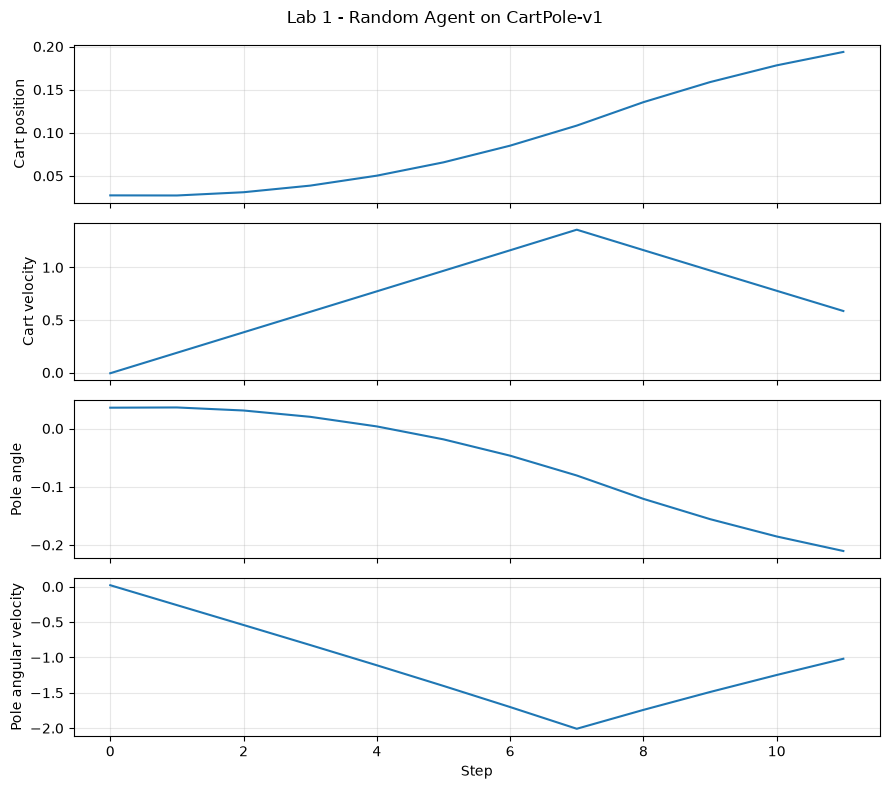

In [6]:
observations = np.asarray(observations)
labels = ["Cart position", "Cart velocity", "Pole angle", "Pole angular velocity"]

fig, axes = plt.subplots(4, 1, figsize=(9, 8), sharex=True)
for i, label in enumerate(labels):
    axes[i].plot(observations[:, i])
    axes[i].set_ylabel(label)
    axes[i].grid(True, alpha=0.3)

axes[-1].set_xlabel("Step")
fig.suptitle("Lab 1 - Random Agent on CartPole-v1")
fig.tight_layout()
plt.show()

env.close()


## learning outcome

The experiment demonstrates the basic RL interaction loop:

**observation/state → action → environment → reward + next observation**

A random agent does not learn a policy, so its performance is unstable. The purpose is to become familiar with standard RL environments, observation/action spaces, rewards and episode termination.
